In [44]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

library(knitr)
library(kableExtra)

## Problem 1

Rows: 161060 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


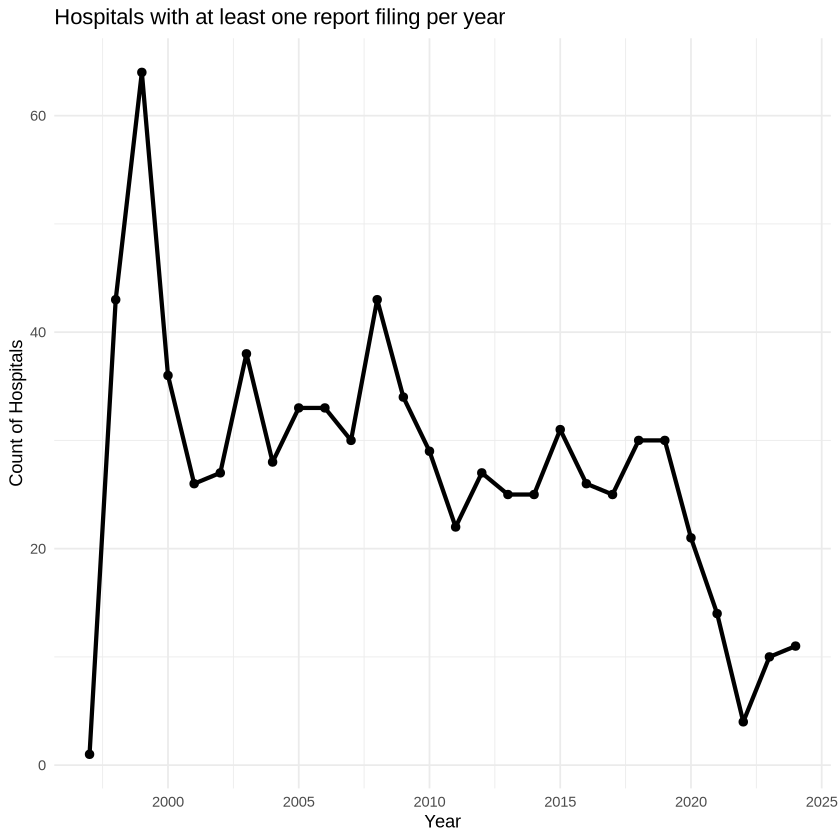

In [45]:
hcris.full <- read_tsv("../data/output/HCRIS_Data.txt")

dup.count <- hcris.full %>% 
    mutate(year = year(fy_end)) %>%
    filter(source == "total for year") %>%
    add_count(provider_number, year, name="total_reports") %>%
    mutate(dup_report = ("total_reports" > 1)) %>%
    distinct(provider_number, year, dup_report) %>%
    group_by(year) %>%
    summarize(duplicates = sum(dup_report))

dup.count %>%
  ggplot(aes(x = year, y = duplicates)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  labs(
    x = "Year",
    y = "Count of Hospitals",
    title = "Hospitals with at least one report filing per year"
  ) +
  theme_minimal()

## Problem 2

In [46]:
hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  group_by(year) %>%
  summarise(unique_hospitals = n_distinct(provider_number)) %>%
  kable(
    col.names = c("Year", "Unique Hospitals"),
    digits    = 0,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Number of Unique Hospitals per Year (2009–2019)"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Number of Unique Hospitals per Year (2009–2019)</caption>
 <thead>
  <tr>
   <th style="text-align:right;font-weight: bold;"> Year </th>
   <th style="text-align:right;font-weight: bold;"> Unique Hospitals </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2009 </td>
   <td style="text-align:right;"> 6100 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2010 </td>
   <td style="text-align:right;"> 6103 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2011 </td>
   <td style="text-align:right;"> 6097 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2012 </td>
   <td style="text-align:right;"> 6140 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2013 </td>
   <td style="text-align:right;"> 6066 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2014 </td>

## Problem 3

Warning message in log(tot_charges):
“NaNs produced”
Warning message:
“Removed 2645 rows containing non-finite values (`stat_ydensity()`).”


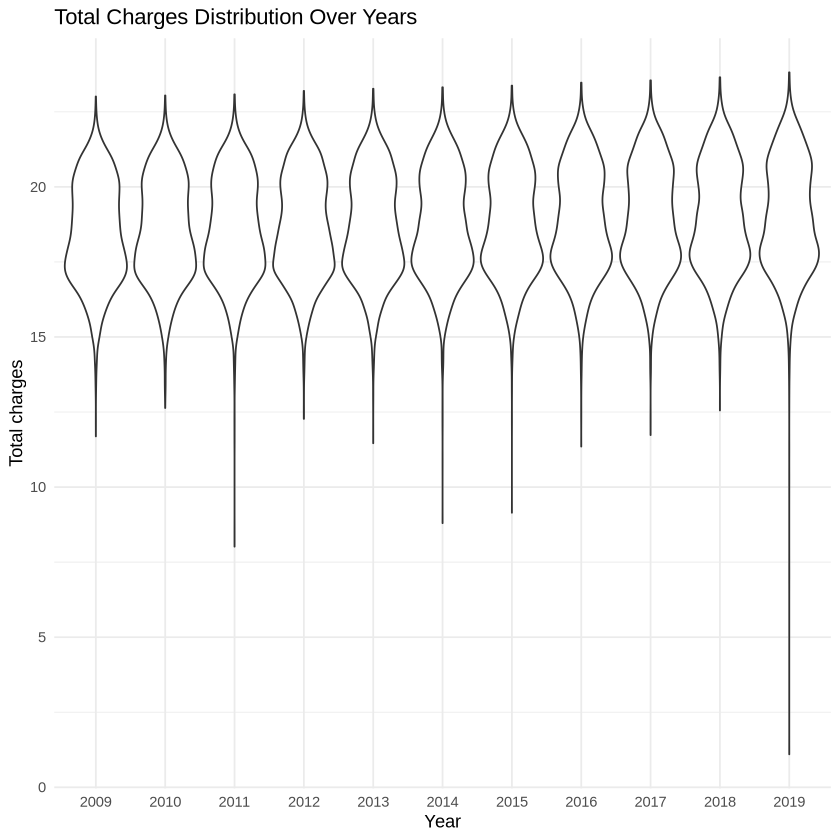

In [47]:
hcris.full %>%
  mutate(year = year(fy_end)) %>%
  filter(year >= 2009, year <= 2019) %>%
  ggplot(aes(x = factor(year), y = log(tot_charges))) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Total Charges Distribution Over Years",
    x = "Year",
    y = "Total charges"
  ) +
  theme_minimal()

## Problem 4

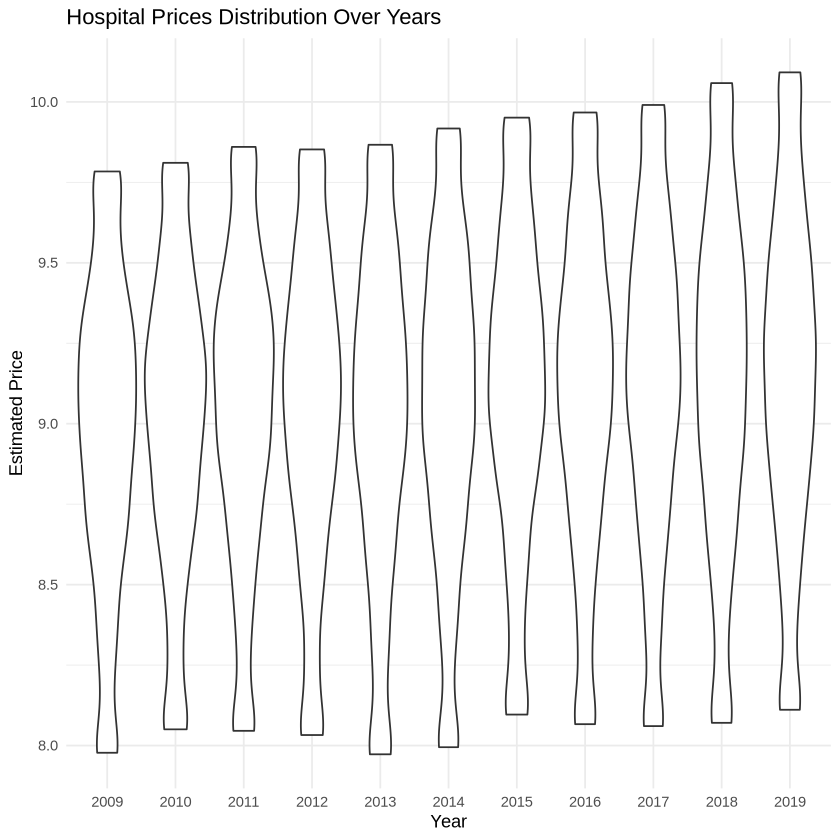

In [48]:
hcris.full %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ggplot(aes(x = factor(year), y = log(price))) +
  geom_violin() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Hospital Prices Distribution Over Years",
    x = "Year",
    y = "Estimated Price"
  ) +
  theme_minimal()

## Problem 5

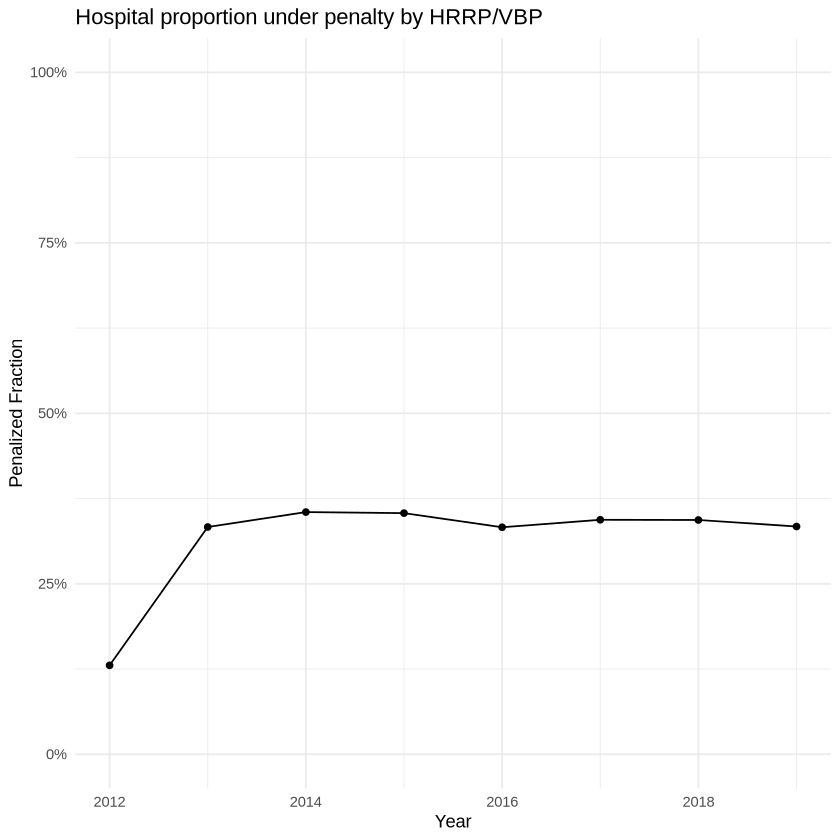

In [49]:
hcris.full %>%
  mutate(
    year = year(fy_end),
    hvbp_payment = ifelse(is.na(hvbp_payment), 0, hvbp_payment),
    hrrp_payment = ifelse(is.na(hrrp_payment), 0, abs(hrrp_payment)),
    penalty = as.numeric((hvbp_payment - hrrp_payment) < 0)
  ) %>%
  filter(year >= 2012, year <= 2019) %>%
  group_by(year) %>%
  summarise(share_penalty = mean(penalty, na.rm = TRUE)) %>%
  ggplot(aes(x = year, y = share_penalty)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  labs(
    title = "Hospital proportion under penalty by HRRP/VBP",
    x = "Year",
    y = "Penalized Fraction"
  ) +
  theme_minimal()

# Estimate ATEs

## Problem 6

In [50]:
# price for each hospital-year
hcris.pricing <- hcris.full %>%
  mutate(
    year = year(fy_end),
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(price > 0) %>%
  group_by(year) %>%
  mutate(
    p05 = quantile(price, 0.05, na.rm = TRUE),
    p95 = quantile(price, 0.95, na.rm = TRUE),
    price = pmin(pmax(price, p05), p95)
  ) %>%
  ungroup() %>%
  select(provider_number, year, price, beds, mcare_discharges, mcaid_discharges, hrrp_payment, hvbp_payment)

# from 2011 until 2014
price.change <- hcris.pricing %>%
  filter(year %in% c(2011, 2014)) %>%
  select(provider_number, year, price) %>%
  pivot_wider(names_from = year, values_from = price, names_prefix = "price_") %>%
  mutate(price_change = price_2014 - price_2011)

# 2012 penalize, change in definition of net penalty
penalty.2012 <- hcris.pricing %>%
  filter(year == 2012) %>%
  mutate(net_penalty = hvbp_payment - hrrp_payment) %>%
  select(provider_number, net_penalty)

# averages before 2012 from 2009-2011
pre.2012 <- hcris.pricing %>%
  filter(year >= 2009, year <= 2011) %>%
  group_by(provider_number) %>%
  summarise(
    avg_beds = mean(beds, na.rm = TRUE),
    avg_mcare = mean(mcare_discharges, na.rm = TRUE),
    avg_mcaid = mean(mcaid_discharges, na.rm = TRUE)
  )

# combined set
hcris.combined <- price.change %>%
  inner_join(penalty.2012, by = "provider_number") %>%
  inner_join(pre.2012, by = "provider_number") %>%
  filter(!is.na(price_change))

In [51]:
ols1 <- lm(price_change ~ net_penalty, data = hcris.combined)
ols2 <- lm(price_change ~ net_penalty + avg_beds, data = hcris.combined)
ols3 <- lm(price_change ~ net_penalty + avg_beds + avg_mcaid, data = hcris.combined)

summary(ols1)
summary(ols2)
summary(ols3)


Call:
lm(formula = price_change ~ net_penalty, data = hcris.combined)

Residuals:
     Min       1Q   Median       3Q      Max 
-11659.0  -1159.8     -9.4   1096.8   8552.3 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 394.526992  95.740329   4.121 4.31e-05 ***
net_penalty  -0.001806   0.001187  -1.521    0.129    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2070 on 599 degrees of freedom
  (1863 observations deleted due to missingness)
Multiple R-squared:  0.003846,	Adjusted R-squared:  0.002183 
F-statistic: 2.313 on 1 and 599 DF,  p-value: 0.1288



Call:
lm(formula = price_change ~ net_penalty + avg_beds, data = hcris.combined)

Residuals:
     Min       1Q   Median       3Q      Max 
-11667.1  -1150.7      0.8   1090.0   8544.5 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 373.295118  95.761793   3.898 0.000108 ***
net_penalty  -0.001747   0.001183  -1.477 0.140289    
avg_beds      0.065421   0.027104   2.414 0.016089 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2062 on 598 degrees of freedom
  (1863 observations deleted due to missingness)
Multiple R-squared:  0.01346,	Adjusted R-squared:  0.01016 
F-statistic: 4.079 on 2 and 598 DF,  p-value: 0.0174



Call:
lm(formula = price_change ~ net_penalty + avg_beds + avg_mcaid, 
    data = hcris.combined)

Residuals:
   Min     1Q Median     3Q    Max 
-11361  -1131     20   1029   7743 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.234e+02  1.084e+02   1.139   0.2551    
net_penalty 3.860e-05  1.225e-03   0.032   0.9749    
avg_beds    6.223e-02  2.666e-02   2.335   0.0199 *  
avg_mcaid   2.077e-01  4.458e-02   4.658 3.94e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2027 on 597 degrees of freedom
  (1863 observations deleted due to missingness)
Multiple R-squared:  0.04805,	Adjusted R-squared:  0.04327 
F-statistic: 10.05 on 3 and 597 DF,  p-value: 1.824e-06


In [52]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.frame(
  Statistic = c("Intercept", "Net Penalty", "Avg Beds", "Avg Medicaid", "Num.Obs.", "R2"),
  `OLS 1` = c(
    round(coef(ols1)["(Intercept)"],  3),
    round(coef(ols1)["net_penalty"],  3),
    NA,
    NA,
    nobs(ols1),
    round(summary(ols1)$r.squared,   3)
  ),
  `OLS 2` = c(
    round(coef(ols2)["(Intercept)"],  3),
    round(coef(ols2)["net_penalty"],  3),
    round(coef(ols2)["avg_beds"],     3),
    NA,
    nobs(ols2),
    round(summary(ols2)$r.squared,   3)
  ),
  `OLS 3` = c(
    round(coef(ols3)["(Intercept)"],  3),
    round(coef(ols3)["net_penalty"],  3),
    round(coef(ols3)["avg_beds"],     3),
    round(coef(ols3)["avg_mcaid"],    3),
    nobs(ols3),
    round(summary(ols3)$r.squared,   3)
  ),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "OLS 1", "OLS 2", "OLS 3"),
    digits    = 3,
    booktabs  = TRUE,
    caption   = "OLS Estimates of Price Change on Penalty Status"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  pack_rows("Coefficients", 1, 4) %>%
  pack_rows("Model Fit",    5, 6)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>OLS Estimates of Price Change on Penalty Status</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:right;font-weight: bold;"> OLS 1 </th>
   <th style="text-align:right;font-weight: bold;"> OLS 2 </th>
   <th style="text-align:right;font-weight: bold;"> OLS 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="4"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:right;"> 394.527 </td>
   <td style="text-align:right;"> 373.295 </td>
   <td style="text-align:right;"> 123.437 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Net Penalty </td>
   <td style="text-align:right;"> -0.002 </td>
   <td style="text-align:right;"> -0

We need the estimated effect on the net penalty is not significant, as observable from the p-value. However, average beds that have a statistically significance maintains the same estimated effect size of around 0.066. Finally, when average Medicaid discharges are included, we see the most prominent significance with the lowest p-value and largest estimate magnitude.

## Problem 7

Warning message:
“Removed 1863 rows containing missing values (`geom_point()`).”


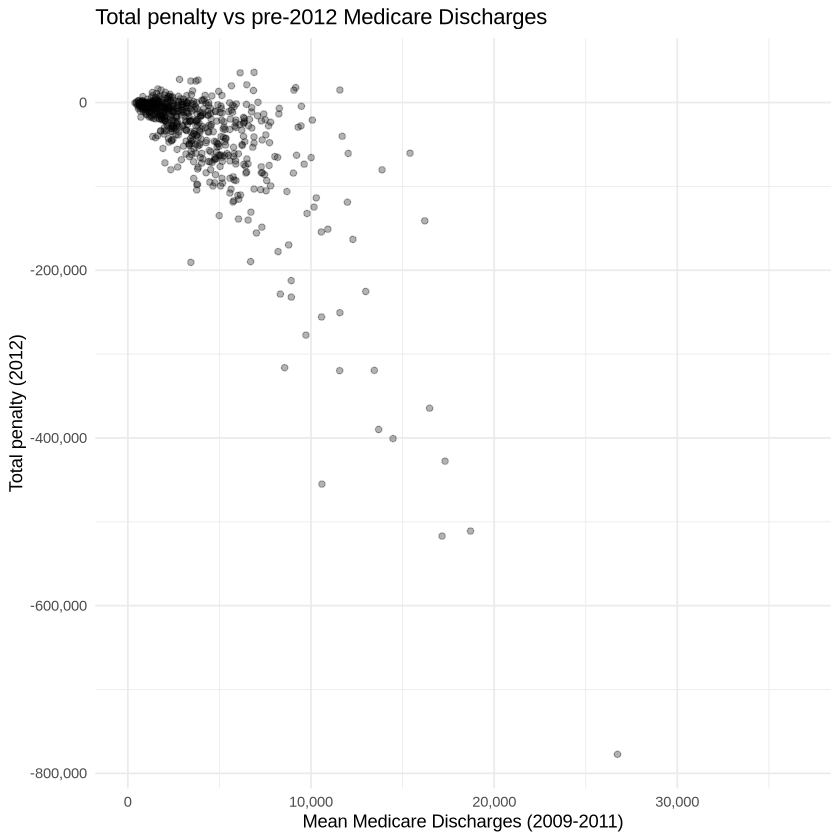

In [53]:
ggplot(hcris.combined, aes(x = avg_mcare, y = net_penalty)) +
  geom_point(alpha = 0.3) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Total penalty vs pre-2012 Medicare Discharges",
    x = "Mean Medicare Discharges (2009-2011)",
    y = "Total penalty (2012)"
  ) +
  theme_minimal()

## Problem 8

In [54]:
library(fixest)

# first stage - net_penalty ~ avg_mcare (instrument)
fs1 <- feols(net_penalty ~ avg_mcare, data = hcris.combined)
fs2 <- feols(net_penalty ~ avg_mcare + avg_beds, data = hcris.combined)
fs3 <- feols(net_penalty ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.combined)

# reduced form - price_change ~ avg_mcare (instrument)
rf1 <- feols(price_change ~ avg_mcare, data = hcris.combined)
rf2 <- feols(price_change ~ avg_mcare + avg_beds, data = hcris.combined)
rf3 <- feols(price_change ~ avg_mcare + avg_beds + avg_mcaid, data = hcris.combined)

cat("---First Stage---\n")
summary(fs1)
summary(fs2)
summary(fs3)

cat("---Reduced Form---\n")
summary(rf1)
summary(rf2)
summary(rf3)

NOTE: 1,863 observations removed because of NA values (LHS: 1,863).

NOTE: 1,863 observations removed because of NA values (LHS: 1,863).

NOTE: 1,863 observations removed because of NA values (LHS: 1,863, RHS: 10).

NOTE: 10 observations removed because of NA values (RHS: 10).



---First Stage---


OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
              Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) 29593.4720 3181.775569   9.30093 < 2.2e-16 ***
avg_mcare     -17.3247    0.643659 -26.91597 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 47,849.1   Adj. R2: 0.546646

OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
                Estimate  Std. Error    t value  Pr(>|t|)    
(Intercept) 29535.430929 3185.302292   9.272411 < 2.2e-16 ***
avg_mcare     -17.342224    0.644793 -26.895781 < 2.2e-16 ***
avg_beds        0.352226    0.630906   0.558286   0.57686    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 47,836.6   Adj. R2: 0.546124

OLS estimation, Dep. Var.: net_penalty
Observations: 601 
Standard-errors: IID 
                Estimate  Std. Error    t value  Pr(>|t|)    
(Intercept) 29124.396496 3216.267995   9.055339 < 2.2e-16 ***
avg_mcare     -17.647248    0.723694 -24.384973 < 2.2e-16 ***
avg_beds        0.346482    0.631009   0.549093   0.58315    
avg_mcaid       1.043941    1.124111   0.928681   0.35343    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 47,802.1   Adj. R2: 0.54602

---Reduced Form---


OLS estimation, Dep. Var.: price_change
Observations: 2,464 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 200.299724  72.119549 2.777329 0.0055223 ** 
avg_mcare     0.013111   0.015037 0.871929 0.3833320    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,342.7   Adj. R2: -9.735e-5

OLS estimation, Dep. Var.: price_change
Observations: 2,464 
Standard-errors: IID 
              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 195.625788  72.085239 2.713812 0.0066978 ** 
avg_mcare     0.009467   0.015107 0.626663 0.5309385    
avg_beds      0.070591   0.030662 2.302253 0.0214040 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,340.2   Adj. R2: 0.001646

OLS estimation, Dep. Var.: price_change
Observations: 2,454 
Standard-errors: IID 
              Estimate Std. Error  t value   Pr(>|t|)    
(Intercept) 150.910043  72.990105  2.06754 0.03878796 *  
avg_mcare    -0.023698   0.017333 -1.36719 0.17168980    
avg_beds      0.067250   0.030635  2.19524 0.02823984 *  
avg_mcaid     0.100579   0.025472  3.94856 0.00008084 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,336.8   Adj. R2: 0.007568

In [55]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)
library(fixest)

data.frame(
  Statistic = c("Intercept", "Avg Medicare", "Avg Beds", "Avg Medicaid", "Num.Obs.", "R2"),

  `FS 1` = c(
    round(coef(fs1)["(Intercept)"], 3),
    round(coef(fs1)["avg_mcare"],   3),
    NA,
    NA,
    nobs(fs1),
    round(r2(fs1)["r2"],            3)
  ),
  `FS 2` = c(
    round(coef(fs2)["(Intercept)"], 3),
    round(coef(fs2)["avg_mcare"],   3),
    round(coef(fs2)["avg_beds"],    3),
    NA,
    nobs(fs2),
    round(r2(fs2)["r2"],            3)
  ),
  `FS 3` = c(
    round(coef(fs3)["(Intercept)"], 3),
    round(coef(fs3)["avg_mcare"],   3),
    round(coef(fs3)["avg_beds"],    3),
    round(coef(fs3)["avg_mcaid"],   3),
    nobs(fs3),
    round(r2(fs3)["r2"],            3)
  ),

  `RF 1` = c(
    round(coef(rf1)["(Intercept)"], 3),
    round(coef(rf1)["avg_mcare"],   3),
    NA,
    NA,
    nobs(rf1),
    round(r2(rf1)["r2"],            3)
  ),
  `RF 2` = c(
    round(coef(rf2)["(Intercept)"], 3),
    round(coef(rf2)["avg_mcare"],   3),
    round(coef(rf2)["avg_beds"],    3),
    NA,
    nobs(rf2),
    round(r2(rf2)["r2"],            3)
  ),
  `RF 3` = c(
    round(coef(rf3)["(Intercept)"], 3),
    round(coef(rf3)["avg_mcare"],   3),
    round(coef(rf3)["avg_beds"],    3),
    round(coef(rf3)["avg_mcaid"],   3),
    nobs(rf3),
    round(r2(rf3)["r2"],            3)
  ),

  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "FS 1", "FS 2", "FS 3", "RF 1", "RF 2", "RF 3"),
    digits    = 3,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "First Stage and Reduced Form Estimates"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  add_header_above(c(" " = 1, "First Stage" = 3, "Reduced Form" = 3)) %>%
  pack_rows("Coefficients", 1, 4) %>%
  pack_rows("Model Fit",    5, 6)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>First Stage and Reduced Form Estimates</caption>
 <thead>
<tr>
<th style="empty-cells: hide;border-bottom:hidden;" colspan="1"></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">First Stage</div></th>
<th style="border-bottom:hidden;padding-bottom:0; padding-left:3px;padding-right:3px;text-align: center; " colspan="3"><div style="border-bottom: 1px solid #ddd; padding-bottom: 5px; ">Reduced Form</div></th>
</tr>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:right;font-weight: bold;"> FS 1 </th>
   <th style="text-align:right;font-weight: bold;"> FS 2 </th>
   <th style="text-align:right;font-weight: bold;"> FS 3 </th>
   <th style="text-align:right;font-weight: bold;"> RF 1 </th>
   <th style="text-align:right;font-weig

We note that in the first stage, net penalty has the largest effect and most prominent statistical significance with average Medicare discharges, whereas in reduced form the specification with average beds recovers the most statistically significant effect against after average Medicare discharges overtaking to be the most prominent in third specification of reduced form against prices with largest effect size, while average beds still stay prominent.

## Problem 9

In [56]:
# IV estimates - price_change ~ net_penalty, instrumented by avg_mcare
iv1 <- feols(price_change ~ 1 | net_penalty ~ avg_mcare, data = hcris.combined)
iv2 <- feols(price_change ~ avg_beds | net_penalty ~ avg_mcare, data = hcris.combined)
iv3 <- feols(price_change ~ avg_beds + avg_mcaid | net_penalty ~ avg_mcare, data = hcris.combined)

summary(iv1)
summary(iv2)
summary(iv3)

NOTE: 1,863 observations removed because of NA values (IV: 1,863/0).

NOTE: 1,863 observations removed because of NA values (IV: 1,863/0).

NOTE: 1,863 observations removed because of NA values (RHS: 10, IV: 1,863/0).



TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     346.956816 104.247038  3.32822 0.00092763 ***
fit_net_penalty  -0.003059   0.001606 -1.90397 0.05739349 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,069.0   Adj. R2: 3.293e-4
F-test (1st stage), net_penalty: stat = 724.5    , p < 2.2e-16 , on 1 and 599 DoF.
                     Wu-Hausman: stat =   1.34689, p = 0.246285, on 1 and 598 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)     330.749880 104.114709  3.17678 0.0015659 ** 
fit_net_penalty  -0.002872   0.001600 -1.79515 0.0731340 .  
avg_beds          0.064888   0.027129  2.39185 0.0170718 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,058.6   Adj. R2: 0.00866
F-test (1st stage), net_penalty: stat = 723.4   , p < 2.2e-16 , on 1 and 598 DoF.
                     Wu-Hausman: stat =   1.0951, p = 0.295767, on 1 and 597 DoF.

TSLS estimation, Dep. Var.: price_change, Endo.: net_penalty, Instr.: avg_mcare
Second stage: Dep. Var.: price_change
Observations: 601 
Standard-errors: IID 
                  Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     138.265444 111.238935 1.242959 2.1437e-01    
fit_net_penalty   0.000766   0.001734 0.441756 6.5883e-01    
avg_beds          0.062418   0.026665 2.340851 1.9568e-02 *  
avg_mcaid         0.215947   0.046738 4.620371 4.6959e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2,021.3   Adj. R2: 0.042703
F-test (1st stage), net_penalty: stat = 594.6     , p < 2.2e-16, on 1 and 597 DoF.
                     Wu-Hausman: stat =   0.351075, p = 0.55373, on 1 and 596 DoF.

In [57]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)
library(fixest)

data.frame(
  Statistic = c("Intercept", "Net Penalty (IV)", "Avg Beds", "Avg Medicaid", "Num.Obs.", "R2"),
  `IV 1` = c(
    round(coef(iv1)["(Intercept)"],          3),
    round(coef(iv1)["fit_net_penalty"],       3),
    NA,
    NA,
    nobs(iv1),
    round(r2(iv1)["r2"],                     3)
  ),
  `IV 2` = c(
    round(coef(iv2)["(Intercept)"],          3),
    round(coef(iv2)["fit_net_penalty"],       3),
    round(coef(iv2)["avg_beds"],             3),
    NA,
    nobs(iv2),
    round(r2(iv2)["r2"],                     3)
  ),
  `IV 3` = c(
    round(coef(iv3)["(Intercept)"],          3),
    round(coef(iv3)["fit_net_penalty"],       3),
    round(coef(iv3)["avg_beds"],             3),
    round(coef(iv3)["avg_mcaid"],            3),
    nobs(iv3),
    round(r2(iv3)["r2"],                     3)
  ),
  check.names = FALSE
) %>%
  kable(
    col.names = c("Statistic", "IV 1", "IV 2", "IV 3"),
    digits    = 3,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "IV Estimates of Price Change on Net Penalty (Instrument: Avg Medicare Discharges)"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  pack_rows("Coefficients", 1, 4) %>%
  pack_rows("Model Fit",    5, 6)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>IV Estimates of Price Change on Net Penalty (Instrument: Avg Medicare Discharges)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:right;font-weight: bold;"> IV 1 </th>
   <th style="text-align:right;font-weight: bold;"> IV 2 </th>
   <th style="text-align:right;font-weight: bold;"> IV 3 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="4"><td colspan="4" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:right;"> 346.957 </td>
   <td style="text-align:right;"> 330.750 </td>
   <td style="text-align:right;"> 138.265 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Net Penalty (IV) </td>
   <td style="text-align:right;"> -0.003 </td>


Here as well we note that with no significant result in the first specification, the second specification with average beds becomes statistically significant, and maintains the same effect size in the third specification when included alongside average Medicaid discharges; however, yet again average Medicaid discharges give the most prominent statistical significance with the largest effect size magnitude.

## Problem 10

LATE accounts for changes in the neighborhood of a policy decision and not throughout the context window. If a policy is implemented starting Year X, it would be misleading to include statistics of years prior to that, when such numbers would be unrelated. IV acts similarly to regression discontinuity in the sense that both give an essence of LATE. Thus, here overall ATE would be polluted by extrapolating too much beyond the policy or decision implementation period, thereby giving noisy or biased results.